In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator

In [2]:
## -- load observed spectra:
# visit 1
dat_wavelengths1, dat_spec1, dat_specerr1 = np.loadtxt("./data/stellarspectra/V1298Tau_NIRISSobs2_fluxcal_medianspectrum.txt", skiprows=1, unpack=True)
# visit 2
dat_wavelengths2, dat_spec2, dat_specerr2 = np.loadtxt("./data/stellarspectra/V1298Tau_NIRISSobs17_fluxcal_medianspectrum.txt", skiprows=1, unpack=True)
dat_wavelengths2 = dat_wavelengths2[3:-49]
dat_spec2 = dat_spec2[3:-49]
dat_specerr2 = dat_specerr2[3:-49]

## -- load best-fit 3-component model
# visit 1
l = np.load('./data/stellarspectra/3comp_models_JWSTgrid_v2.npz')
mod_wavelengths1 = l['waves']
mod_full1 = l['yfull']
mod_phot1 = l['yphot']
mod_cool1 = l['ycool']
mod_hot1 = l['yhot']
del l
fcool1 = 0.22369036129
fhot1 = 0.2831230353
fphot1 = 1.-(fcool1+fhot1)
# visit 2
l = np.load('./data/stellarspectra/visit2_3comp_models_JWSTgrid_v1.npz')
mod_wavelengths2 = l['waves'][3:-49]
mod_full2 = l['yfull'][3:-49]
mod_phot2 = l['yphot'][3:-49]
mod_cool2 = l['ycool'][3:-49]
mod_hot2 = l['yhot'][3:-49]
fits2 = l['fits']
fcool2 = fits2[3]
fhot2 = fits2[4]
fphot2 = 1.-(fcool2+fhot2)

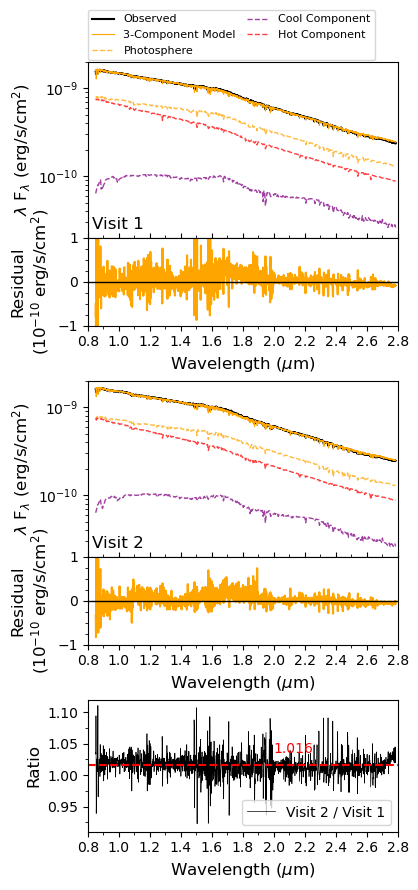

In [3]:
fig = plt.figure(figsize=(4, 10))
# Outer GridSpec: 3 panel groups stacked vertically
outer_gs = gridspec.GridSpec(nrows=3, ncols=1, figure=fig, hspace=0.25, height_ratios=[2,2,1])

# -- top (visit 1 spectrum and fits)
inner_gs_A = gridspec.GridSpecFromSubplotSpec(nrows=2, ncols=1, subplot_spec=outer_gs[0], hspace=0., height_ratios=[2,1])
axA = fig.add_subplot(inner_gs_A[0])
axA.tick_params(labelbottom=False)
axa = fig.add_subplot(inner_gs_A[1], sharex=axA)
axA.tick_params(axis='x', which='both', direction='in')

axA.plot(dat_wavelengths1, dat_wavelengths1*dat_spec1, c='black', zorder=1, label='Observed')
axA.plot(mod_wavelengths1, mod_wavelengths1*mod_full1, c='orange', ls='solid', lw=0.8, zorder=3, label='3-Component Model')
axA.plot(mod_wavelengths1[::5], mod_wavelengths1[::5]*fphot1*mod_phot1[::5], c='orange', ls='--', lw=1, alpha=0.75, zorder=2, label='Photosphere')
axA.plot(mod_wavelengths1[::5], mod_wavelengths1[::5]*fcool1*mod_cool1[::5], c='purple', ls='--', lw=1, alpha=0.75, zorder=2, label='Cool Component')
axA.plot(mod_wavelengths1[::5], mod_wavelengths1[::5]*fhot1*mod_hot1[::5], c='red', ls='--', lw=1, alpha=0.75, zorder=2, label='Hot Component')
axA.set_yscale('log')
axA.set_ylabel(r'$\lambda$ F$_{\lambda}$ (erg/s/cm$^2$)', fontsize=12)
axA.set_xlim(0.8, 2.8)
axA.set_ylim(2e-11,2e-9)

axa.axhline(0., c='black', lw=1, zorder=10)
axa.plot(dat_wavelengths1, ((dat_wavelengths1*dat_spec1)-(mod_wavelengths1*mod_full1))*1.e10, c='orange')
axa.set_ylabel('Residual\n'+r'(10$^{-10}$ erg/s/cm$^2$)', fontsize=12)
axa.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
axa.set_ylim(-1,1)
axa.xaxis.set_major_locator(MultipleLocator(0.2))
axa.xaxis.set_minor_locator(MultipleLocator(0.1))
axa.yaxis.set_major_locator(MultipleLocator(1))
axa.yaxis.set_minor_locator(MultipleLocator(0.25))

# -- middle (visit 2 spectrum and fits)
inner_gs_B = gridspec.GridSpecFromSubplotSpec(nrows=2, ncols=1, subplot_spec=outer_gs[1], hspace=0., height_ratios=[2,1])
axB = fig.add_subplot(inner_gs_B[0])
axB.tick_params(labelbottom=False)
axb = fig.add_subplot(inner_gs_B[1], sharex=axB)
axB.tick_params(axis='x', which='both', direction='in')

axB.plot(dat_wavelengths2, dat_wavelengths2*dat_spec2, c='black', zorder=1, label='Obs.')
axB.plot(mod_wavelengths2, mod_wavelengths2*mod_full2, c='orange', ls='solid', lw=0.8, zorder=3, label='Full Model')
axB.plot(mod_wavelengths2[::5], mod_wavelengths2[::5]*fphot1*mod_phot2[::5], c='orange', ls='--', lw=1, alpha=0.75, zorder=2, label='Photosphere')
axB.plot(mod_wavelengths2[::5], mod_wavelengths2[::5]*fcool1*mod_cool2[::5], c='purple', ls='--', lw=1, alpha=0.75, zorder=2, label='Cool Component')
axB.plot(mod_wavelengths2[::5], mod_wavelengths2[::5]*fhot1*mod_hot2[::5], c='red', ls='--', lw=1, alpha=0.75, zorder=2, label='Hot Component')
axB.set_yscale('log')
axB.set_ylabel(r'$\lambda$ F$_{\lambda}$ (erg/s/cm$^2$)', fontsize=12)
axB.set_xlim(0.8, 2.8)
axB.set_ylim(2e-11,2e-9)

axb.axhline(0., c='black', lw=1, zorder=10)
axb.plot(dat_wavelengths2, ((dat_wavelengths2*dat_spec2)-(mod_wavelengths2*mod_full2))*1.e10, c='orange')
axb.set_ylabel('Residual\n'+r'(10$^{-10}$ erg/s/cm$^2$)', fontsize=12)
axb.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
axb.set_ylim(-1,1)
axb.xaxis.set_major_locator(MultipleLocator(0.2))
axb.xaxis.set_minor_locator(MultipleLocator(0.1))
axb.yaxis.set_major_locator(MultipleLocator(1))
axb.yaxis.set_minor_locator(MultipleLocator(0.25))

# -- bottom (compare both spectra)
med_ratio = np.nanmedian((dat_spec2/dat_spec1))

axC = fig.add_subplot(outer_gs[2])
axC.plot(dat_wavelengths2, (dat_spec2/dat_spec1), c='black', lw=0.5, label='Visit 2 / Visit 1')
axC.axhline(med_ratio, c='red', ls='--')
axC.text(2.0, med_ratio+0.02, '%.3f'%(med_ratio), fontsize=10, c='red', alpha=1)
axC.set_xlim(0.8, 2.8)
axC.set_ylim(0.91,1.12)
axC.xaxis.set_major_locator(MultipleLocator(0.2))
axC.xaxis.set_minor_locator(MultipleLocator(0.1))
axC.yaxis.set_major_locator(MultipleLocator(0.05))
axC.yaxis.set_minor_locator(MultipleLocator(0.025))
axC.set_ylabel('Ratio', fontsize=12)
axC.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
axC.legend(loc='lower right')

axA.legend(loc=(0,1.01), fontsize=8, ncol=2, columnspacing=1)
axA.text(0.015, 0.05, 'Visit 1', fontsize=12, c='black', transform=axA.transAxes)
axB.text(0.015, 0.05, 'Visit 2', fontsize=12, c='black', transform=axB.transAxes)
plt.savefig('./figures/Figure1_stellarspectra.pdf', dpi=600, bbox_inches='tight')
plt.show()